# Import Library

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM,Dropout
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"]="3"
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [ ]:
data=pd.read_csv('/content/metadata-gga-txt.csv')

In [ ]:
data.head()

,Time,DO,Sample_name
0,1.0,282.720001,N4-10-5-01042024-Q=49.81mL_phút-3.txt
1,2.0,282.720001,N4-10-5-01042024-Q=49.81mL_phút-3.txt
2,3.0,282.779999,N4-10-5-01042024-Q=49.81mL_phút-3.txt
3,4.0,282.739990,N4-10-5-01042024-Q=49.81mL_phút-3.txt
4,5.0,282.739990,N4-10-5-01042024-Q=49.81mL_phút-3.txt


# Run with multiple Samples

## Encoder-Decoder LSTM

### Train

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from keras.optimizers import AdamW
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dropout, Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error
import numpy as np
import tensorflow as tf

# Đặt seed để đảm bảo tính ngẫu nhiên
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Load data
data = pd.read_csv('/content/metadata-gga-txt.csv')

# List all sample names
sample_names = data['Sample_name'].unique()

# Initialize empty lists to store evaluation results
all_val_losses = []
all_test_losses = []
all_train_rmse = []
all_test_rmse = []
lookback = 7

# Define model with reduced number of neurons
model = Sequential([
    # Encoder
    LSTM(128, activation='relu', input_shape=(1, lookback)),
    RepeatVector(lookback), # This repeats the context vector for the decoder

    # Decoder
    LSTM(128, activation='relu', return_sequences=True),
    LSTM(64, activation='relu'), # Additional LSTM layer to process sequences
    Dense(1) # Final output layer to match the shape of y_true
    # TimeDistributed(Dense(1)), # Applies Dense layer to each time step of the output sequence
])

# Compile model with different learning rate
model.compile(optimizer='adam', loss='mse')
# model.compile(optimizer=AdamW(learning_rate=0.001), loss='huber')

# Theo dõi loss
sample_loss_history = {}

class LossHistory(Callback):
    def __init__(self, sample_name):
        super().__init__()
        self.sample_name = sample_name
        self.loss_history = []

    def on_epoch_end(self, epoch, logs=None):
        self.loss_history.append(logs.get("loss"))

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, verbose=1, mode="min"),
    ModelCheckpoint(filepath="best_model_h5.keras", monitor="val_loss", mode="min", save_best_only=True, save_weights_only=False, verbose=0)
]
count = 0
print("len(sample_name)", len(sample_names))

# Feed data into train
for sample_name in sample_names:
    print(f"Processing {sample_name}...")
    print(count)
    # Filter data for the current sample_name
    one_sample_data = data[data['Sample_name'] == sample_name].copy()
    one_sample_data.reset_index(drop=True, inplace=True)
    one_sample_data.drop(['Sample_name'], axis=1, inplace=True)
    one_sample_data.drop("Time", axis=1, inplace=True)
    one_sample_data = one_sample_data.values
    one_sample_data = one_sample_data.astype("float32")

    # Split data into train and test sets
    def split_data(dataframe, train_size, val_size):
        train_end = int(len(dataframe) * train_size)
        val_end = int(len(dataframe) * (train_size + val_size))
        train = dataframe[:train_end]
        val = dataframe[train_end:val_end]
        test = dataframe[val_end:]
        return train, val, test

    train, val, test = split_data(one_sample_data, 0.60, 0.20)

    # Scale data
    scaler_train = MinMaxScaler(feature_range=(0, 1))
    train = scaler_train.fit_transform(train)
    scaler_val = MinMaxScaler(feature_range=(0, 1))
    val = scaler_val.fit_transform(val)
    scaler_test = MinMaxScaler(feature_range=(0, 1))
    test = scaler_test.fit_transform(test)

    # Create features
    def create_features(data, lookback):
        X, Y = [], []
        for i in range(lookback, len(data)):
            X.append(data[i - lookback:i, 0])
            Y.append(data[i, 0])
        return np.array(X), np.array(Y)

    X_train, y_train = create_features(train, lookback)
    X_val, y_val = create_features(val, lookback)
    X_test, y_test = create_features(test, lookback)

    X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
    X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    # Tạo LossHistory callback cho mỗi sample_name
    loss_history_callback = LossHistory(sample_name)
    callbacks_with_history = callbacks + [loss_history_callback]

    # Train model with different batch size
    model.fit(x=X_train,
              y=y_train,
              epochs=100,
              batch_size=32,
              validation_data=(X_val, y_val),
              callbacks=callbacks,
              shuffle=False,
              verbose=0)


    # Lưu loss history
    sample_loss_history[sample_name] = loss_history_callback.loss_history

    # Evaluate model
    val_loss = model.evaluate(X_val, y_val, batch_size=32, verbose=0)
    # print(f"\nValidation loss: {100.0 * val_loss:.1f}%")

    test_loss = model.evaluate(X_test, y_test, batch_size=32, verbose=0)
    # print(f"\nTest loss: {100.0 * test_loss:.1f}%")

    train_predict = model.predict(X_train, verbose=0)
    val_predict = model.predict(X_val, verbose=0)
    test_predict = model.predict(X_test, verbose=0)

    train_predict = scaler_train.inverse_transform(train_predict)
    val_predict = scaler_val.inverse_transform(val_predict)
    test_predict = scaler_test.inverse_transform(test_predict)

    y_train = scaler_train.inverse_transform(y_train)
    y_val = scaler_val.inverse_transform(y_val)
    y_test = scaler_train.inverse_transform(y_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_predict))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))

    # print(f"Train RMSE: {train_rmse:.4f}")
    # print(f"Validation RMSE: {val_rmse:.4f}")
    # print(f"Test RMSE: {test_rmse:.4f}")

    # Append results to lists
    all_val_losses.append(val_loss)
    all_test_losses.append(test_loss)
    all_train_rmse.append(train_rmse)
    all_test_rmse.append(test_rmse)
    count +=1
# Save the model after training
model.save("enc-dec_lstm_model.h5")

# Print overall evaluation results
print("\nOverall evaluation results:")
print(f"Average val loss: {np.mean(all_val_losses) * 100:.1f}%")
print(f"Average test loss: {np.mean(all_test_losses) * 100:.1f}%")
print(f"Average train RMSE: {np.mean(all_train_rmse):.4f}")
print(f"Average test RMSE: {np.mean(all_test_rmse):.4f}")

len(sample_name) 157
Processing N4-10-5-01042024-Q=49.81mL_phút-3.txt...
0
Epoch 15: early stopping
Processing N4-10-5-27032024-Q=50.45mL_phút-1.txt...
1
Epoch 20: early stopping
Processing N4-10-5-29032024-Q=50.81mL_phút-2.txt...
2
Epoch 10: early stopping
Processing N4-15-10-01042024-Q=49.88mL-phút-2.txt...
3
Epoch 10: early stopping
Processing N4-15-10-27032024-Q=49.66mL_phút-1.txt...
4
Epoch 25: early stopping
Processing N4-5-0-01042024-Q=49.99mL_phút-2.txt...
5
Epoch 10: early stopping
Processing N4-5-0-29032024-Q=50.19mL_phút-1.txt...
6
Epoch 10: early stopping
Processing U1-10-5-02042024-Q=49.74mL_phút-4.txt...
7
Epoch 15: early stopping
Processing U1-10-5-03042024-Q=50.41mL_phút-5.txt...
8
Epoch 10: early stopping
Processing U1-12.5-7.5-04042024-Q=49.9mL_phút-1.txt...
9
Epoch 10: early stopping
Processing U1-12.5-7.5-08042024-Q=50mL_phút-2.txt...
10
Epoch 10: early stopping
Processing U1-15-10-02042024-Q=49.81mL-phút-3.txt...
11
Epoch 33: early stopping
Processing U1-15-10-0304


Overall evaluation results:
Average val loss: 0.1%
Average test loss: 0.1%
Average train RMSE: 0.2322
Average test RMSE: 2.3193


### Test


Validation loss: 0.0%

Test loss: 0.0%
Train RMSE: 1.4268
Validation RMSE: 0.2615
Test RMSE: 26.3712


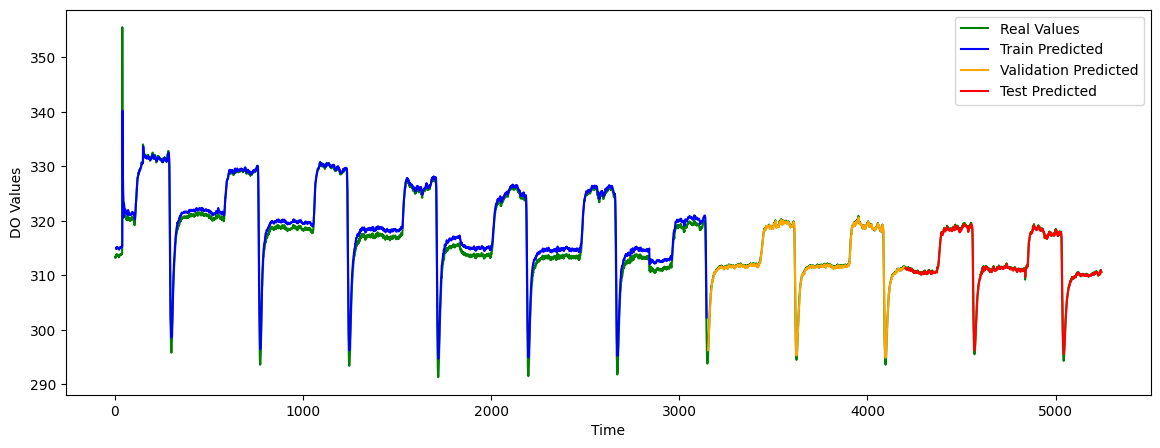

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.optimizers import AdamW
from keras.layers import LSTM, Dropout, Dense
from keras.regularizers import l2

# # Load the trained model
# model = load_model('/content/final_model.h5')

lookback = 7

# Recreate the model architecture
# Define model with reduced number of neurons
model = Sequential([
    # Encoder
    LSTM(128, activation='relu', input_shape=(1, lookback)),
    RepeatVector(lookback), # This repeats the context vector for the decoder

    # Decoder
    LSTM(128, activation='relu', return_sequences=True),
    LSTM(64, activation='relu'), # Additional LSTM layer to process sequences
    Dense(1) # Final output layer to match the shape of y_true
    # TimeDistributed(Dense(1)), # Applies Dense layer to each time step of the output sequence
])

# Load the model weights
# model.load_weights('/content/final_new_model.weights.h5')
model.load_weights('/content/enc-dec_lstm_model.h5')

# model.compile(optimizer=AdamW(learning_rate=0.001), loss='huber') # optimizer = adam hoặc adamW
model.compile(optimizer='adam', loss='mse')

# Now you can use the model to make predictions
# For example:
# predictions = model.predict(your_input_data)


# Load data
data = pd.read_csv('/content/metadata-gga-txt.csv')
sample_name = 'U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt'

# Filter data for the specified sample_name
one_sample_data = data[data['Sample_name'] == sample_name].copy()
one_sample_data.reset_index(drop=True, inplace=True)
one_sample_data.drop(['Sample_name'], axis=1, inplace=True)
one_sample_data.drop("Time", axis=1, inplace=True)
one_sample_data = one_sample_data.values
one_sample_data = one_sample_data.astype("float32")

# Split data into train and test sets
def split_data(dataframe, train_size, val_size):
    train_end = int(len(dataframe) * train_size)
    val_end = int(len(dataframe) * (train_size + val_size))
    train = dataframe[:train_end]
    val = dataframe[train_end:val_end]
    test = dataframe[val_end:]
    return train, val, test

train, val, test = split_data(one_sample_data, 0.60, 0.20)

# Scale data
scaler_train = MinMaxScaler(feature_range=(0, 1))
train = scaler_train.fit_transform(train)
scaler_val = MinMaxScaler(feature_range=(0, 1))
val = scaler_val.fit_transform(val)
scaler_test = MinMaxScaler(feature_range=(0, 1))
test = scaler_test.fit_transform(test)

# Create features
def create_features(data, lookback):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        Y.append(data[i, 0])
    return np.array(X), np.array(Y)

X_train, y_train = create_features(train, lookback)
X_val, y_val = create_features(val, lookback)
X_test, y_test = create_features(test, lookback)

X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Evaluate model
val_loss = model.evaluate(X_val, y_val, batch_size=32, verbose=0)
print(f"\nValidation loss: {100.0 * val_loss:.1f}%")

test_loss = model.evaluate(X_test, y_test, batch_size=32, verbose=0)
print(f"\nTest loss: {100.0 * test_loss:.1f}%")

train_predict = model.predict(X_train, verbose=0)
val_predict = model.predict(X_val, verbose=0)
test_predict = model.predict(X_test, verbose=0)

train_predict = scaler_train.inverse_transform(train_predict)
val_predict = scaler_val.inverse_transform(val_predict)
test_predict = scaler_test.inverse_transform(test_predict)

y_train = scaler_train.inverse_transform(y_train)
y_val = scaler_val.inverse_transform(y_val)
y_test = scaler_train.inverse_transform(y_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
val_rmse = np.sqrt(mean_squared_error(y_val, val_predict))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

# Prepare data for visualization
result_data = data[data['Sample_name'] == sample_name].copy()
result_data.reset_index(drop=True, inplace=True) # Reset index for result_data
train_prediction_data = result_data[lookback:len(train)]
val_prediction_data = result_data[len(train)+lookback:len(train)+len(val)]
test_prediction_data = result_data[len(train)+len(val)+lookback:]

train_prediction_data["Predicted"] = train_predict
val_prediction_data["Predicted"] = val_predict
test_prediction_data["Predicted"] = test_predict

# Plotting
plt.figure(figsize=(14, 5))
plt.plot(result_data.index, result_data["DO"], color = "green", label="Real Values")
plt.plot(train_prediction_data.index, train_prediction_data["Predicted"], color="blue", label="Train Predicted")
plt.plot(val_prediction_data.index, val_prediction_data["Predicted"], color="orange", label="Validation Predicted")
plt.plot(test_prediction_data.index, test_prediction_data["Predicted"], color="red", label="Test Predicted")
plt.xlabel("Time")
plt.ylabel("DO Values")
plt.legend()
plt.show()
